




# **Brain Tumor Classification**


---


This project trains on images of Brain MRI scans and then classifies each image into one of the following four categories:

*   Glioma Tumor
*   Meningioma Tumor
*   Pituitary Tumor
*   No Tumor

---



## 1. Install dependencies

Run this cell in Colab if any package is missing. You can skip it if your environment already has TensorFlow, OpenCV, scikit-learn, and Streamlit installed.

In [1]:
# Uncomment if needed
!pip install -q tensorflow opencv-python-headless scikit-learn streamlit pandas matplotlib seaborn pillow

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\ACER\\anaconda3\\Lib\\site-packages\\~-mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.



## 2. Import libraries and set reproducibility

In [3]:
from pathlib import Path
import json
import os
import random
import shutil
import subprocess

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


## 3. Download the dataset


In [4]:
DATA_REPO_URL = "https://github.com/nazianafis/Brain-MRI-Classification.git"
REPO_DIR = Path("Brain-MRI-Classification")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", DATA_REPO_URL], check=True)
else:
    print(f"{REPO_DIR} already exists, skipping clone.")

## 4. Project configuration

For CPU training, I kept the image size at 224×224 and used a small batch size. The default backbone is `MobileNetV2` because it trains faster on CPU. If you can wait longer, you can change `BACKBONE` to `EfficientNetV2B0`.

In [5]:
RAW_TRAIN_DIR = Path("Brain-MRI-Classification/Brain-MRI/Training")
RAW_TEST_DIR = Path("Brain-MRI-Classification/Brain-MRI/Testing")

CROP_TRAIN_DIR = Path("data/processed/train")
CROP_TEST_DIR = Path("data/processed/test")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 8
FINE_TUNE_EPOCHS = 3
BACKBONE = "MobileNetV2"  # CPU-friendly. Optional: "EfficientNetV2B0"

CLASS_NAMES = sorted([p.name for p in RAW_TRAIN_DIR.iterdir() if p.is_dir()])
print("Classes:", CLASS_NAMES)

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


## 5. Robust brain-region cropping function

This function uses thresholding and contours to crop the visible brain region. If cropping fails, it returns the original image instead of crashing.

In [6]:
def crop_brain_region_bgr(image_bgr, plot=False):
    """Crop the visible brain region from a BGR MRI image.

    Returns the original image if no reliable contour is found.
    """
    if image_bgr is None or image_bgr.size == 0:
        return None

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image_bgr

    largest_contour = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest_contour) < 100:
        return image_bgr

    x, y, w, h = cv2.boundingRect(largest_contour)
    cropped = image_bgr[y:y+h, x:x+w]

    if cropped.size == 0:
        return image_bgr

    if plot:
        original_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(original_rgb)
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(cropped_rgb)
        axes[1].set_title("Cropped")
        axes[1].axis("off")
        plt.show()

    return cropped

## 6. Crop and save the dataset

This replaces the repeated class-by-class loops in the original notebook. It also prevents the `no_tumor` images from being overwritten by giving every saved image a unique filename.

In [7]:
def prepare_clean_directory(path: Path, rebuild: bool = False):
    if rebuild and path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def crop_and_save_dataset(source_dir: Path, target_dir: Path, class_names, rebuild: bool = False):
    prepare_clean_directory(target_dir, rebuild=rebuild)

    for class_name in class_names:
        src_class_dir = source_dir / class_name
        dst_class_dir = target_dir / class_name
        dst_class_dir.mkdir(parents=True, exist_ok=True)

        image_paths = sorted([
            p for p in src_class_dir.iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        saved_count = 0
        for idx, image_path in enumerate(tqdm(image_paths, desc=f"Processing {class_name}")):
            image = cv2.imread(str(image_path))
            cropped = crop_brain_region_bgr(image)
            if cropped is None:
                continue

            resized = cv2.resize(cropped, IMG_SIZE, interpolation=cv2.INTER_AREA)
            save_path = dst_class_dir / f"{idx:05d}.jpg"
            cv2.imwrite(str(save_path), resized)
            saved_count += 1

        print(f"Saved {saved_count} images to {dst_class_dir}")


REBUILD_CROPPED_DATA = True
crop_and_save_dataset(RAW_TRAIN_DIR, CROP_TRAIN_DIR, CLASS_NAMES, rebuild=REBUILD_CROPPED_DATA)
crop_and_save_dataset(RAW_TEST_DIR, CROP_TEST_DIR, CLASS_NAMES, rebuild=REBUILD_CROPPED_DATA)

Processing glioma_tumor: 100%|██████████| 926/926 [00:15<00:00, 61.24it/s]


Saved 926 images to data\processed\train\glioma_tumor


Processing meningioma_tumor: 100%|██████████| 937/937 [00:14<00:00, 66.18it/s]


Saved 937 images to data\processed\train\meningioma_tumor


Processing no_tumor: 100%|██████████| 501/501 [00:07<00:00, 64.75it/s]


...

Saved 5 images to data\processed\test\meningioma_tumor


Processing no_tumor: 100%|██████████| 5/5 [00:00<00:00, 75.29it/s]


Saved 5 images to data\processed\test\no_tumor


Processing pituitary_tumor: 100%|██████████| 5/5 [00:00<00:00, 50.46it/s]

Saved 5 images to data\processed\test\pituitary_tumor


## 7. Visualize sample processed images

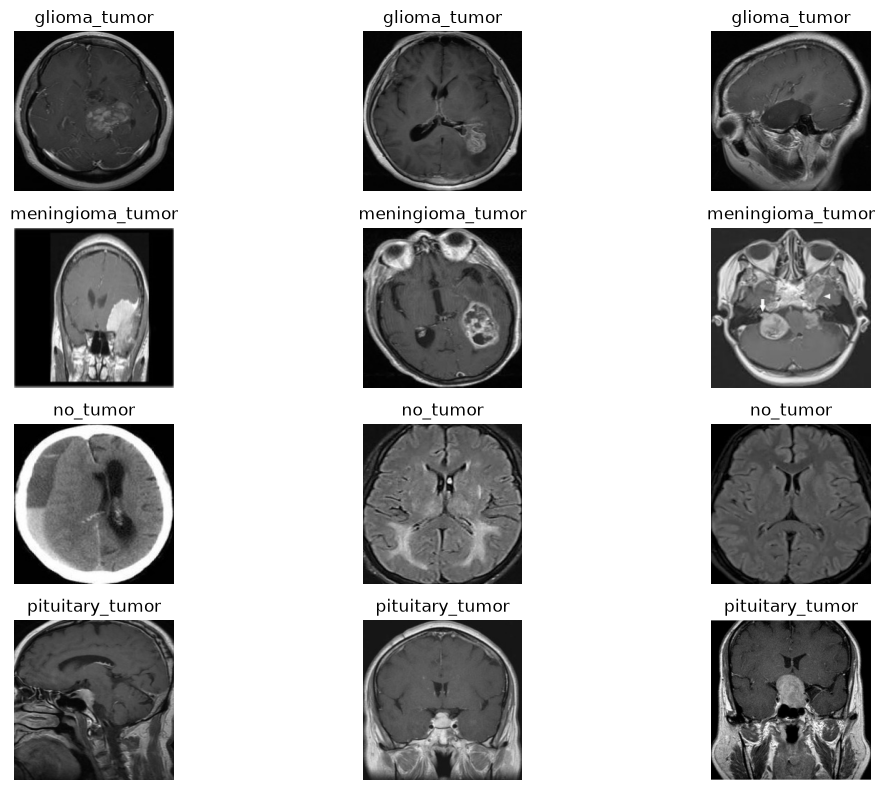

In [9]:
def show_sample_images(data_dir: Path, class_names, samples_per_class=3):
    plt.figure(figsize=(12, 8))
    plot_idx = 1
    for class_name in class_names:
        image_paths = list((data_dir / class_name).glob("*.jpg"))[:samples_per_class]
        for image_path in image_paths:
            image = cv2.imread(str(image_path))
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.subplot(len(class_names), samples_per_class, plot_idx)
            plt.imshow(image_rgb)
            plt.title(class_name)
            plt.axis("off")
            plot_idx += 1
    plt.tight_layout()
    plt.show()

show_sample_images(CROP_TRAIN_DIR, CLASS_NAMES, samples_per_class=3)

## 8. Load train, validation, and test datasets

The training set is split into training and validation subsets. The test set is loaded separately and is not augmented.

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    CROP_TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    CROP_TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    CROP_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
print("Class order used by the model:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 3265 files belonging to 4 classes.
Using 2612 files for training.
Found 3265 files belonging to 4 classes.
Using 653 files for validation.
Found 20 files belonging to 4 classes.
Class order used by the model: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


## 9. Build a CPU-friendly transfer learning model

The model uses a pretrained CNN backbone and a small custom classification head. The backbone is frozen at first, which makes training much faster on CPU.

In [11]:
def build_model(num_classes: int, backbone: str = "MobileNetV2"):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name="mri_image")

    # Conservative augmentation. Avoid aggressive transforms for medical images.
    x = tf.keras.layers.RandomRotation(0.05, seed=SEED)(inputs)
    x = tf.keras.layers.RandomZoom(0.10, seed=SEED)(x)
    x = tf.keras.layers.RandomContrast(0.10, seed=SEED)(x)

    if backbone == "EfficientNetV2B0":
        base_model = tf.keras.applications.EfficientNetV2B0(
            include_top=False,
            weights="imagenet",
            input_shape=(*IMG_SIZE, 3),
            include_preprocessing=True,
        )
        x = base_model(x, training=False)
    elif backbone == "MobileNetV2":
        x = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1)(x)
        base_model = tf.keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=(*IMG_SIZE, 3),
        )
        x = base_model(x, training=False)
    else:
        raise ValueError("Choose 'MobileNetV2' or 'EfficientNetV2B0'.")

    base_model.trainable = False

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="tumor_class")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f"brain_tumor_{backbone.lower()}")
    return model, base_model

model, base_model = build_model(num_classes=len(class_names), backbone=BACKBONE)
model.summary()

Model: "brain_tumor_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mri_image (InputLayer)               │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast (RandomContrast)     │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tumor_class (Dense)                  │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,268,228 (8.65 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 10. Compile and train the model

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

checkpoint_path = MODEL_DIR / "best_brain_tumor_model.keras"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/8


C:\Users\ACER\Stanislaus\Projects\Streamlit\brain_tumor_classification\myenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.3645 - loss: 1.7318
Epoch 1: val_accuracy improved from None to 0.51608, saving model to models\best_brain_tumor_model.keras

Epoch 1: finished saving model to models\best_brain_tumor_model.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 122s 706ms/step - accuracy: 0.3645 - loss: 1.7318 - val_accuracy: 0.5161 - val_loss: 1.1612 - learning_rate: 1.0000e-04
Epoch 2/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.5218 - loss: 1.2358
Epoch 2: val_accuracy improved from 0.51608 to 0.61103, saving model to models\best_brain_tumor_model.keras

Epoch 2: finished saving model to models\best_brain_tumor_model.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 126s 612ms/step - accuracy: 0.5218 - loss: 1.2358 - val_accuracy: 0.6110 - val_loss: 0.9915 - learning_rate: 1.0000e-04
Epoch 3/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.6126 - loss: 1.0262
Epoch 3: val_accuracy improved from 0.61103 to 0.64625, saving model to models\best_brain_tumor_

## 11. Optional fine-tuning

This cell is optional. Fine-tuning may improve accuracy, but it is slower on CPU. Keep `RUN_FINE_TUNING = False` unless you have time to wait.

In [19]:
RUN_FINE_TUNING = True

if RUN_FINE_TUNING:
    base_model.trainable = True

    # Keep most layers frozen and fine-tune only the last few layers.
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    fine_tune_history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks,
    )
else:
    print("Skipping fine-tuning. Set RUN_FINE_TUNING = True to enable it.")

Epoch 1/3


C:\Users\ACER\Stanislaus\Projects\Streamlit\brain_tumor_classification\myenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.6493 - loss: 0.9134
Epoch 1: val_accuracy did not improve from 0.72894
164/164 ━━━━━━━━━━━━━━━━━━━━ 122s 659ms/step - accuracy: 0.6493 - loss: 0.9134 - val_accuracy: 0.7106 - val_loss: 0.8492 - learning_rate: 1.0000e-05
Epoch 2/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.7148 - loss: 0.7367
Epoch 2: val_accuracy did not improve from 0.72894
164/164 ━━━━━━━━━━━━━━━━━━━━ 144s 671ms/step - accuracy: 0.7148 - loss: 0.7367 - val_accuracy: 0.6845 - val_loss: 0.9834 - learning_rate: 1.0000e-05
Epoch 3/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.7531 - loss: 0.6655
Epoch 3: val_accuracy did not improve from 0.72894

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
164/164 ━━━━━━━━━━━━━━━━━━━━ 93s 567ms/step - accuracy: 0.7531 - loss: 0.6655 - val_accuracy: 0.7167 - val_loss: 0.9336 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 3.


## 12. Plot training curves

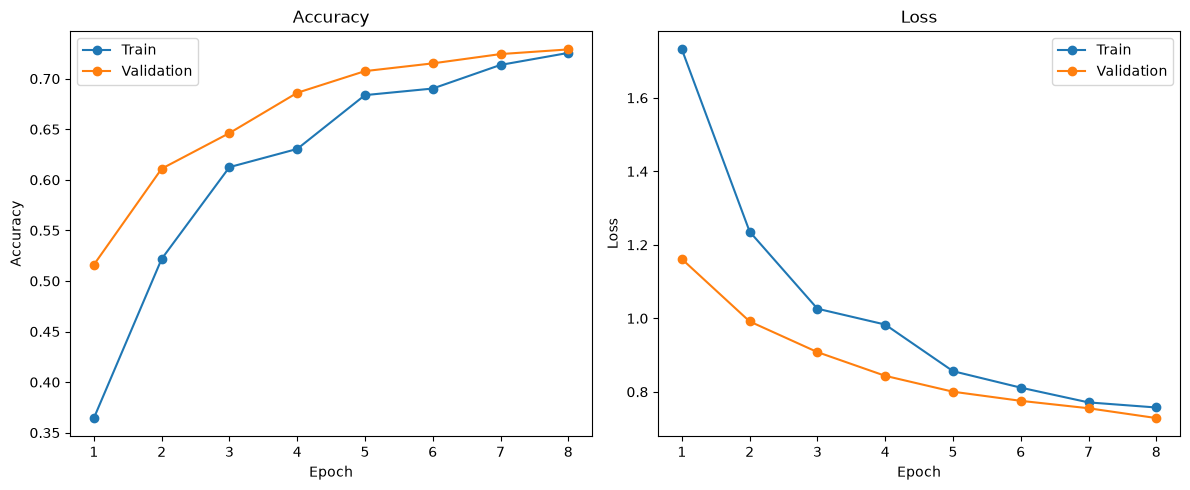

In [20]:
def plot_training_curves(history):
    metrics = history.history
    epochs_range = range(1, len(metrics["accuracy"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, metrics["accuracy"], marker="o", label="Train")
    plt.plot(epochs_range, metrics["val_accuracy"], marker="o", label="Validation")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, metrics["loss"], marker="o", label="Train")
    plt.plot(epochs_range, metrics["val_loss"], marker="o", label="Validation")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

## 13. Evaluate on the test set

In [21]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.6000 - loss: 1.3048
Test accuracy: 0.6000
Test loss: 1.3048


## 14. Classification report and confusion matrix

                  precision    recall  f1-score   support

    glioma_tumor       0.50      0.60      0.55         5
meningioma_tumor       1.00      0.40      0.57         5
        no_tumor       1.00      0.40      0.57         5
 pituitary_tumor       0.50      1.00      0.67         5

        accuracy                           0.60        20
       macro avg       0.75      0.60      0.59        20
    weighted avg       0.75      0.60      0.59        20



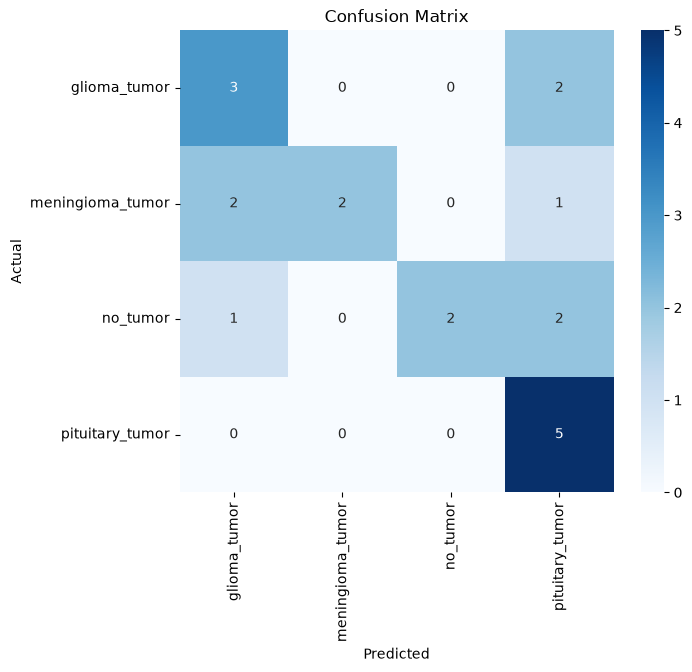

In [22]:
y_true = []
y_pred = []

for images, labels in test_ds:
    probabilities = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probabilities, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 15. Test prediction on one image

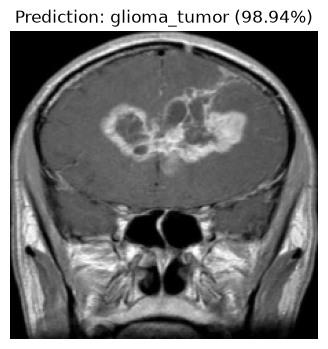

,class,probability
0,glioma_tumor,0.989362
3,pituitary_tumor,0.007322
1,meningioma_tumor,0.003309
2,no_tumor,0.000007


In [23]:
def predict_single_image(image_path: Path):
    image_bgr = cv2.imread(str(image_path))
    cropped = crop_brain_region_bgr(image_bgr)
    resized = cv2.resize(cropped, IMG_SIZE, interpolation=cv2.INTER_AREA)
    image_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

    model_input = np.expand_dims(image_rgb.astype("float32"), axis=0)
    probabilities = model.predict(model_input, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))

    plt.figure(figsize=(4, 4))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[predicted_index]} ({probabilities[predicted_index]:.2%})")
    plt.show()

    return pd.DataFrame({"class": class_names, "probability": probabilities}).sort_values("probability", ascending=False)

sample_image = next((CROP_TEST_DIR / class_names[0]).glob("*.jpg"))
predict_single_image(sample_image)

## 16. Save the trained model

In [24]:
final_model_path = MODEL_DIR / "brain_tumor_mri_model.keras"
class_names_path = MODEL_DIR / "class_names.json"

model.save(final_model_path)

with open(class_names_path, "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)

print(f"Saved model to: {final_model_path}")
print(f"Saved class names to: {class_names_path}")

Saved model to: models\brain_tumor_mri_model.keras
Saved class names to: models\class_names.json


---